Lecture: AI I - Advanced 

Previous:
[**Chapter 3.1: PyTorch Ligning**](../01_lightning.ipynb)

---

# Exercise 3.1: PyTorch Lightning

> Hint: When doing the exercises put your solution in the designated "Solution" section:
> ```python
> # Solution (put your code here)
> ```

## Task 1: Diabetes Regression with Multi-Layer Perceptron 

The diabetes dataset contains 442 samples with 10 baseline variables (age, sex, BMI, blood pressure, and 6 blood serum measurements). The target is a quantitative measure of disease progression one year after baseline.

**Tasks**
- Data Exploration & Understanding
- Data preparation
- Build Model a Multi-Layer Perceptron for regression but use PyTorch Lightning
- Train the model 
- Evaluate the model performance using appropriate regression metrics (e.g. MSE, MAE) and Tensorboard

In [14]:
# prerequisites (don't edit this block)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

In [15]:
# Solution (put your code here)
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)  # set random seed for reproducibility

x_scaled = StandardScaler().fit_transform(x)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_scaled, y, test_size=0.4, random_state=42
 )
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42
 )

batch_size = 16
train_loader = DataLoader(TensorDataset(torch.FloatTensor(x_train), torch.FloatTensor(y_train).unsqueeze(1)), batch_size=batch_size, shuffle=True, num_workers=23)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(x_val), torch.FloatTensor(y_val).unsqueeze(1)), batch_size=batch_size, num_workers=23)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(x_test), torch.FloatTensor(y_test).unsqueeze(1)), batch_size=batch_size, num_workers=23)

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L

class DiabetesRegressor(L.LightningModule):
    """
    Lightning module for diabetes regression.
    """
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=1, learning_rate=0.001, dropout=0.2):
        super().__init__()
        self.save_hyperparameters()

        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x

    def _step(self, step_name, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        mae = torch.mean(torch.abs(y_hat - y))

        self.log(f'{step_name}_loss', loss, prog_bar=True)
        self.log(f'{step_name}_mae', mae, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step('train', batch, batch_idx)

    def validation_step(self, batch, batch_idx):
        self._step('val', batch, batch_idx)

    def test_step(self, batch, batch_idx):
        self._step('test', batch, batch_idx)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {'optimizer': optimizer}

In [17]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

model = DiabetesRegressor(hidden_dim=64, learning_rate=0.001, dropout=0.2)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        mode='min',
        verbose=True
    ),
    ModelCheckpoint(
        monitor='val_loss',
        dirpath='./data/01_lightning/models/',
        filename='diabetes-{epoch:02d}-{val_loss:.4f}',
        save_top_k=3,
        mode='min'
    ),
]

trainer = L.Trainer(
    max_epochs=100,
    accelerator='auto',
    devices='auto',
    callbacks=callbacks,
    logger=TensorBoardLogger('./data/01_lightning/logs', name='diabetes_regressor'),
    log_every_n_steps=5,
    enable_progress_bar=True
)
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/workspaces/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspaces/chapter/03_advanced/exercise/data/01_lightning/models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer1  │ Linear  │    704 │ train │     0 │
│ 1 │ dropout │ Dropout │      0 │ train │     0 │
│ 2 │ layer2  │ Linear  │     65 │ train │     0 │
│ 3 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 769                                                                                              
Non-trainable params: 0                                                                                            
Total params: 769                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/workspaces/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

Metric val_loss improved by 24.930 >= min_delta = 0.0. New best score: 3994.782


Metric val_loss improved by 21.767 >= min_delta = 0.0. New best score: 3973.015


Metric val_loss improved by 20.133 >= min_delta = 0.0. New best score: 3952.882


Metric val_loss improved by 20.500 >= min_delta = 0.0. New best score: 3932.382


Metric val_loss improved by 22.522 >= min_delta = 0.0. New best score: 3909.860
`Trainer.fit` stopped: `max_epochs=100` reached.


In [18]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = DiabetesRegressor.load_from_checkpoint(best_model_path)
best_model.eval()

DiabetesRegressor(
  (layer1): Linear(in_features=10, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=64, out_features=1, bias=True)
  (loss_fn): MSELoss()
)

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = next(best_model.parameters()).device
x_test_tensor = torch.FloatTensor(x_test).to(device)

with torch.no_grad():
    y_pred = best_model(x_test_tensor).squeeze(1).cpu().numpy()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R^2: {r2:.4f}")

Test MSE: 4353.2086
Test MAE: 52.6761
Test R^2: 0.2474


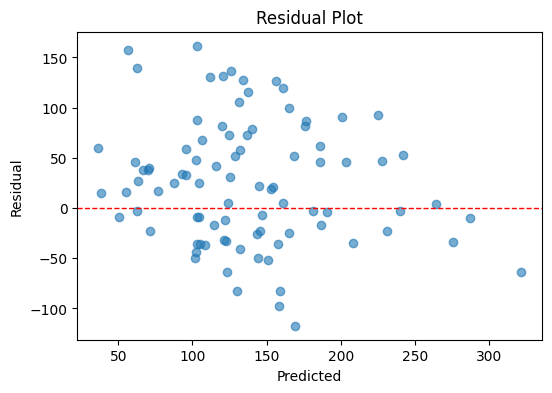

In [20]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

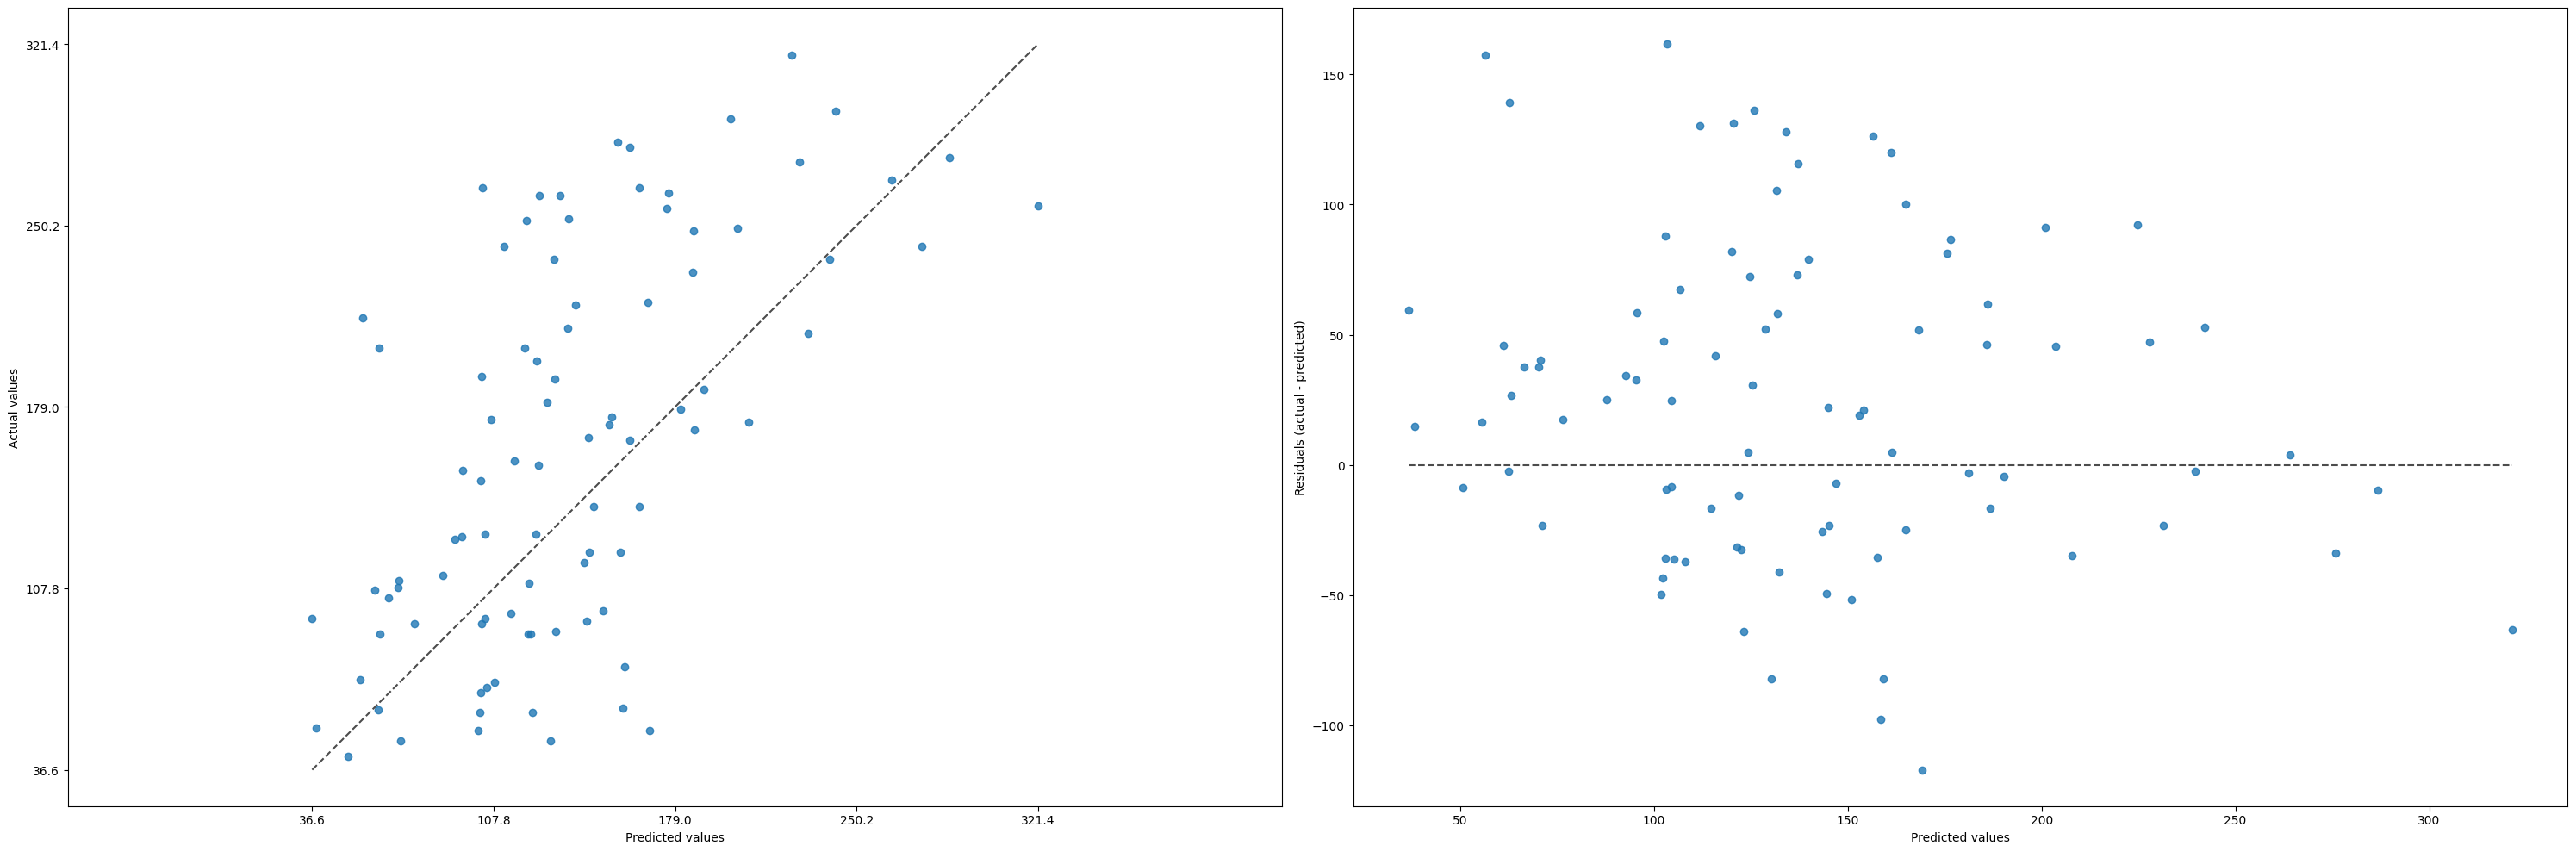

In [21]:
from sklearn.metrics import PredictionErrorDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))

device = next(best_model.parameters()).device
x_test_tensor = torch.FloatTensor(x_test).to(device)

with torch.no_grad():
    y_pred = best_model(x_test_tensor).squeeze(1).cpu().numpy()

y_true = y_test

PredictionErrorDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax1,
    kind='actual_vs_predicted',
)
PredictionErrorDisplay.from_predictions(
    y_true,
    y_pred,
    kind='residual_vs_predicted',
    ax=ax2,
)
fig.tight_layout()

In [23]:
# Test case (don't edit this block)
assert True

---

Lecture: AI I - Advanced 

Next: [**Chapter 4.1.1: Convolutional Neural Networks**](../../04_excursus/01_cv/01_cnn.ipynb)